## CSV 2: Missing Values & Sparse Sales Data

**Description**  
A simulated real-world CRM export with incomplete and sparsely populated data due to skipped fields, unconverted leads, and partial historical backfills. Missing values appear across lifecycle dates, revenue fields, and categorical columns.

**Purpose / What It Tests**
- Missing-value detection and reporting
- Transparency in how the platform handles incomplete data
- Avoidance of silent row drops or unsupported assumptions
- Correct KPI and trend computation despite data gaps


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(7)

N_ROWS = 2500

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

products = [
    (101, "CRM Pro", "Software"),
    (102, "Analytics Suite", "Software"),
    (103, "Sales Booster", "Software"),
    (201, "POS Terminal", "Hardware"),
]

regions = ["North America", "Europe", "Asia"]
channels = ["Inbound", "Outbound", "Partner"]
salespeople = [f"Salesperson_{i}" for i in range(1, 11)]

rows = []

for i in range(N_ROWS):
    lead_date = random_date(start_date, end_date)

    # 25% of rows have no close_date (open/lost leads)
    close_date = (
        lead_date + timedelta(days=random.randint(5, 25))
        if random.random() > 0.25 else None
    )

    order_date = close_date if close_date and random.random() > 0.1 else None

    product = random.choice(products)
    units = random.randint(1, 15)

    # 20% missing revenue
    revenue = units * random.randint(100, 1500) if random.random() > 0.2 else None

    rows.append({
        "order_id": f"O-{100000+i}" if random.random() > 0.05 else None,
        "opportunity_id": f"OPP-{200000+i}",
        "customer_id": f"C-{random.randint(1000, 5000)}",
        "lead_date": lead_date,
        "close_date": close_date,
        "order_date": order_date,
        "revenue": revenue,
        "units": units if random.random() > 0.1 else None,
        "product_id": product[0],
        "product_name": product[1],
        "category": product[2],
        "salesperson": random.choice(salespeople) if random.random() > 0.15 else None,
        "region": random.choice(regions),
        "channel": random.choice(channels) if random.random() > 0.2 else None,
        "stage": random.choice(["Lead", "Qualified", "Won", "Lost"]),
        "is_returning": random.choice([True, False]) if random.random() > 0.1 else None,
    })

df = pd.DataFrame(rows)

df.to_csv("sales_missing_values.csv", index=False)
print("CSV generated: sales_missing_values.csv")


CSV generated: sales_missing_values.csv


Validation Code

In [2]:
import pandas as pd

df = pd.read_csv("sales_missing_values.csv")

# Missing values per column
missing_summary = df.isnull().mean().sort_values(ascending=False)
print("Missing value ratio per column:\n", missing_summary)

# Assertions to ensure dataset is truly sparse
assert missing_summary.max() > 0.15, "❌ Not enough missing data introduced"
assert df["revenue"].isnull().sum() > 0, "❌ Revenue should have missing values"
assert df["salesperson"].isnull().sum() > 0, "❌ Salesperson should be missing in some rows"
assert df["order_date"].isnull().sum() > 0, "❌ Order dates should be missing"

print("✅ Missing-value conditions validated.")


Missing value ratio per column:
 order_date        0.3276
close_date        0.2596
revenue           0.2020
channel           0.1996
salesperson       0.1532
units             0.0988
is_returning      0.0980
order_id          0.0508
customer_id       0.0000
opportunity_id    0.0000
lead_date         0.0000
product_id        0.0000
category          0.0000
product_name      0.0000
region            0.0000
stage             0.0000
dtype: float64
✅ Missing-value conditions validated.


Gold Truth Analysis

Total Revenue: 12943771.0
Win Rate: 0.2428


C:\Users\KRONOS\AppData\Local\Temp\ipykernel_70544\4289699075.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


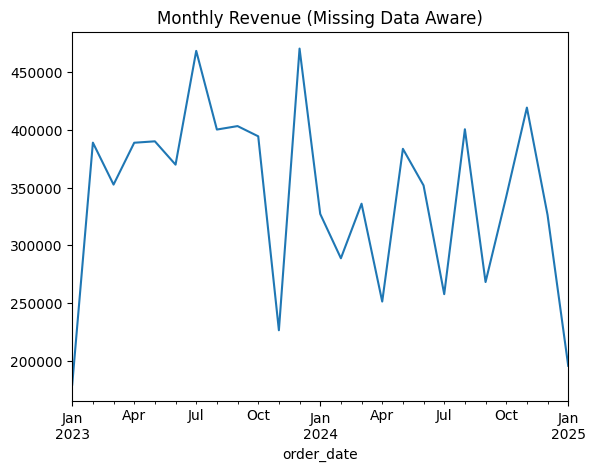

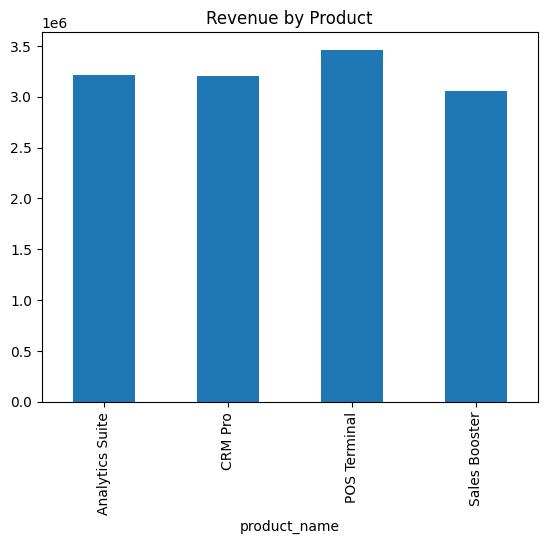

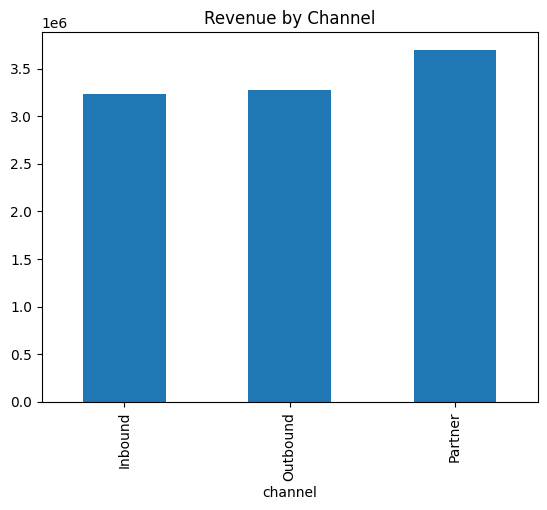

Average Sales Cycle (days): 14.943273905996758


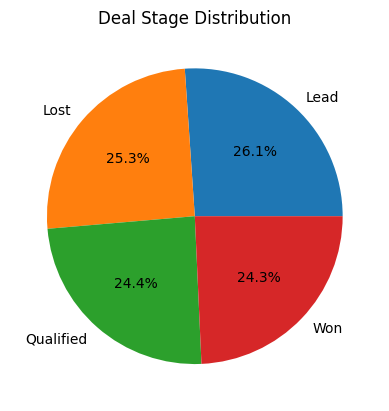

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "sales_missing_values.csv",
    parse_dates=["lead_date", "close_date", "order_date"]
)

# ---------------------------
# KPI 1: Total Revenue (ignore missing)
# ---------------------------
total_revenue = df["revenue"].sum(skipna=True)
print("Total Revenue:", total_revenue)

# ---------------------------
# KPI 2: Win Rate
# ---------------------------
win_rate = (df["stage"] == "Won").mean()
print("Win Rate:", win_rate)

# ---------------------------
# Trend 1: Monthly Revenue (only valid orders)
# ---------------------------
monthly_revenue = (
    df.dropna(subset=["order_date", "revenue"])
      .set_index("order_date")
      .resample("M")["revenue"]
      .sum()
)

monthly_revenue.plot(title="Monthly Revenue (Missing Data Aware)")
plt.show()

# ---------------------------
# Trend 2: Revenue by Product
# ---------------------------
product_revenue = (
    df.dropna(subset=["revenue"])
      .groupby("product_name")["revenue"]
      .sum()
)

product_revenue.plot(kind="bar", title="Revenue by Product")
plt.show()

# ---------------------------
# Trend 3: Revenue by Channel (Sparse)
# ---------------------------
channel_revenue = (
    df.dropna(subset=["channel", "revenue"])
      .groupby("channel")["revenue"]
      .sum()
)

channel_revenue.plot(kind="bar", title="Revenue by Channel")
plt.show()

# ---------------------------
# KPI 3: Average Sales Cycle (only closed deals)
# ---------------------------
closed = df.dropna(subset=["lead_date", "close_date"])
avg_cycle = (closed["close_date"] - closed["lead_date"]).dt.days.mean()
print("Average Sales Cycle (days):", avg_cycle)

# ---------------------------
# Trend 4: Deal Stage Distribution
# ---------------------------
stage_counts = df["stage"].value_counts()
stage_counts.plot(kind="pie", autopct="%1.1f%%", title="Deal Stage Distribution")
plt.ylabel("")
plt.show()
